# 06 - Gradient Boosting from Scratch (Second-Order / Newton Boosting)

**Advanced Machine Learning** | Haydar Kilic

Boosting builds an additive model greedily,
$f_t(x) = f_{t-1}(x) + \eta\,T_t(x)$, where each tree is fitted to the *current*
errors. Expanding the loss to second order around $f_{t-1}$,

$$\mathcal{L}^{(t)} \simeq \sum_i \Bigl[g_i T_t(x_i) + \tfrac12 h_i T_t(x_i)^2\Bigr]
+ \tfrac{\lambda}{2}\sum_j w_j^2 + \gamma |T_t| ,
\qquad g_i = \partial_f \ell,\; h_i = \partial_f^2 \ell ,$$

and minimising over the leaf values gives, for leaf $j$ with instance set $I_j$,

$$w_j^\star = -\frac{G_j}{H_j + \lambda},
\qquad \text{split gain} =
\tfrac12\Bigl[\frac{G_L^2}{H_L+\lambda}+\frac{G_R^2}{H_R+\lambda}-\frac{G^2}{H+\lambda}\Bigr]-\gamma .$$

This is exactly what the `GradientTree` in the toolkit cell computes -- squared-error
regression is the special case $g_i = -y_i,\ h_i = 1$.

In [1]:
# =========================================================================
# Toolkit for this lecture: the implementations used below, inlined so the
# notebook runs on its own (NumPy / SciPy / Matplotlib only).
# Read them alongside the derivations -- each block mirrors one formula.
# =========================================================================
from __future__ import annotations

import numpy as np
from dataclasses import dataclass, field

# --- datasets ------------------------------------------------------

def _rng(random_state: int | np.random.Generator | None) -> np.random.Generator:
    if isinstance(random_state, np.random.Generator):
        return random_state
    return np.random.default_rng(random_state)

def make_friedman1(n_samples=200, n_features=10, noise=1.0, random_state=None):
    r"""Friedman #1 benchmark.

    .. math::
        y = 10\sin(\pi x_0 x_1) + 20 (x_2 - 0.5)^2 + 10 x_3 + 5 x_4 + \varepsilon

    Only the first five features are informative -- the rest are distractors,
    which makes it a good stress test for sparse models and tree ensembles.
    """
    if n_features < 5:
        raise ValueError("Friedman #1 needs at least 5 features.")
    rng = _rng(random_state)
    X = rng.uniform(size=(n_samples, n_features))
    y = (
        10.0 * np.sin(np.pi * X[:, 0] * X[:, 1])
        + 20.0 * (X[:, 2] - 0.5) ** 2
        + 10.0 * X[:, 3]
        + 5.0 * X[:, 4]
    )
    y = y + noise * rng.standard_normal(n_samples)
    return X, y

def make_two_moons(n_samples=200, noise=0.2, random_state=None):
    """Two interleaving half circles -- the canonical non-linear 2-class toy."""
    rng = _rng(random_state)
    n_out = n_samples // 2
    n_in = n_samples - n_out
    t_out = np.linspace(0, np.pi, n_out)
    t_in = np.linspace(0, np.pi, n_in)
    outer = np.stack([np.cos(t_out), np.sin(t_out)], axis=1)
    inner = np.stack([1 - np.cos(t_in), 0.5 - np.sin(t_in)], axis=1)
    X = np.vstack([outer, inner]) + noise * rng.standard_normal((n_samples, 2))
    y = np.hstack([np.zeros(n_out, dtype=int), np.ones(n_in, dtype=int)])
    perm = rng.permutation(n_samples)
    return X[perm], y[perm]

def train_test_split(*arrays, test_size=0.25, random_state=None, stratify=None):
    """Shuffle-split arrays, optionally stratified by ``stratify`` labels."""
    if not arrays:
        raise ValueError("At least one array is required.")
    n = len(arrays[0])
    for arr in arrays:
        if len(arr) != n:
            raise ValueError("All arrays must share the same first dimension.")
    rng = _rng(random_state)

    if stratify is None:
        idx = rng.permutation(n)
        n_test = int(round(test_size * n))
        test_idx, train_idx = idx[:n_test], idx[n_test:]
    else:
        stratify = np.asarray(stratify)
        train_parts, test_parts = [], []
        for value in np.unique(stratify):
            group = np.flatnonzero(stratify == value)
            group = group[rng.permutation(len(group))]
            n_test = int(round(test_size * len(group)))
            test_parts.append(group[:n_test])
            train_parts.append(group[n_test:])
        train_idx = np.concatenate(train_parts)
        test_idx = np.concatenate(test_parts)
        train_idx = train_idx[rng.permutation(len(train_idx))]
        test_idx = test_idx[rng.permutation(len(test_idx))]

    out = []
    for arr in arrays:
        arr = np.asarray(arr)
        out.extend([arr[train_idx], arr[test_idx]])
    return tuple(out)

# --- metrics -------------------------------------------------------

_EPS = 1e-12

def mse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(np.mean((y_true - y_pred) ** 2))

def r2_score(y_true, y_pred):
    r"""Coefficient of determination :math:`1 - SS_{res}/SS_{tot}`."""
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return float(1.0 - ss_res / (ss_tot + _EPS))

def accuracy(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.mean(y_true == y_pred))

def log_loss(y_true, p_pred, eps=1e-15):
    """Binary cross-entropy on probabilities (natural log)."""
    y_true = np.asarray(y_true, float)
    p = np.clip(np.asarray(p_pred, float), eps, 1 - eps)
    return float(-np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p)))

def roc_auc(y_true, scores):
    """Rank-based AUC (Mann-Whitney U), ties handled with average ranks."""
    y_true = np.asarray(y_true, int)
    scores = np.asarray(scores, float)
    n_pos = int(np.sum(y_true == 1))
    n_neg = int(np.sum(y_true == 0))
    if n_pos == 0 or n_neg == 0:
        raise ValueError("ROC AUC needs both classes to be present.")

    order = np.argsort(scores, kind="mergesort")
    sorted_scores = scores[order]
    ranks = np.empty(len(scores), dtype=float)
    i = 0
    while i < len(scores):
        j = i
        while j + 1 < len(scores) and sorted_scores[j + 1] == sorted_scores[i]:
            j += 1
        avg_rank = 0.5 * (i + j) + 1.0
        ranks[order[i : j + 1]] = avg_rank
        i = j + 1

    rank_sum_pos = ranks[y_true == 1].sum()
    return float((rank_sum_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg))

# --- trees ---------------------------------------------------------

@dataclass
class _Node:
    value: float = 0.0
    feature: int = -1
    threshold: float = 0.0
    gain: float = 0.0
    left: _Node | None = field(default=None, repr=False)
    right: _Node | None = field(default=None, repr=False)
    n_samples: int = 0

    @property
    def is_leaf(self):
        return self.left is None

class GradientTree:
    """Regression tree fitted to gradient/Hessian pairs."""

    def __init__(self, max_depth=3, min_samples_leaf=1, min_child_weight=1e-3,
                 reg_lambda=1.0, gamma=0.0, max_features=None, random_state=None):
        self.max_depth = int(max_depth)
        self.min_samples_leaf = int(min_samples_leaf)
        self.min_child_weight = float(min_child_weight)
        self.reg_lambda = float(reg_lambda)
        self.gamma = float(gamma)
        self.max_features = max_features
        self.random_state = random_state

    # ------------------------------------------------------------ utilities
    def _leaf_value(self, g_sum, h_sum):
        return float(-g_sum / (h_sum + self.reg_lambda))

    def _objective(self, g_sum, h_sum):
        return float(g_sum**2 / (h_sum + self.reg_lambda))

    def _feature_subset(self, n_features, rng):
        if self.max_features is None:
            return np.arange(n_features)
        if isinstance(self.max_features, float):
            k = max(1, int(round(self.max_features * n_features)))
        else:
            k = min(int(self.max_features), n_features)
        return rng.choice(n_features, size=k, replace=False)

    # ------------------------------------------------------------- building
    def _best_split(self, X, g, h, rng):
        n, n_features = X.shape
        G, H = g.sum(), h.sum()
        parent = self._objective(G, H)
        best = (0.0, -1, 0.0)  # gain, feature, threshold

        for j in self._feature_subset(n_features, rng):
            order = np.argsort(X[:, j], kind="mergesort")
            xs, gs, hs = X[order, j], g[order], h[order]
            g_cum, h_cum = np.cumsum(gs)[:-1], np.cumsum(hs)[:-1]
            # only positions where the value actually changes are valid splits
            valid = xs[:-1] < xs[1:]
            if not valid.any():
                continue
            left_count = np.arange(1, n)
            valid &= (left_count >= self.min_samples_leaf)
            valid &= ((n - left_count) >= self.min_samples_leaf)
            valid &= (h_cum >= self.min_child_weight)
            valid &= ((H - h_cum) >= self.min_child_weight)
            if not valid.any():
                continue

            gain = 0.5 * (
                g_cum**2 / (h_cum + self.reg_lambda)
                + (G - g_cum) ** 2 / (H - h_cum + self.reg_lambda)
                - parent
            ) - self.gamma
            gain = np.where(valid, gain, -np.inf)
            idx = int(np.argmax(gain))
            if gain[idx] > best[0]:
                best = (float(gain[idx]), int(j), float(0.5 * (xs[idx] + xs[idx + 1])))
        return best

    def _build(self, X, g, h, depth, rng):
        node = _Node(value=self._leaf_value(g.sum(), h.sum()), n_samples=len(X))
        if depth >= self.max_depth or len(X) < 2 * self.min_samples_leaf:
            return node
        gain, feature, threshold = self._best_split(X, g, h, rng)
        if feature < 0 or gain <= 0.0:
            return node
        mask = X[:, feature] <= threshold
        if mask.all() or (~mask).all():
            return node
        node.feature, node.threshold, node.gain = feature, threshold, gain
        self.feature_importances_[feature] += gain
        node.left = self._build(X[mask], g[mask], h[mask], depth + 1, rng)
        node.right = self._build(X[~mask], g[~mask], h[~mask], depth + 1, rng)
        return node

    def fit(self, X, g, h=None):
        X = np.asarray(X, float)
        g = np.asarray(g, float)
        h = np.ones_like(g) if h is None else np.asarray(h, float)
        self.feature_importances_ = np.zeros(X.shape[1])
        rng = np.random.default_rng(self.random_state)
        self.root_ = self._build(X, g, h, 0, rng)
        return self

    # ------------------------------------------------------------ inference
    def predict(self, X):
        X = np.asarray(X, float)
        out = np.empty(len(X))
        for i, row in enumerate(X):
            node = self.root_
            while not node.is_leaf:
                node = node.left if row[node.feature] <= node.threshold else node.right
            out[i] = node.value
        return out

    @property
    def n_leaves_(self):
        def count(node):
            return 1 if node.is_leaf else count(node.left) + count(node.right)

        return count(self.root_)

    @property
    def depth_(self):
        def depth(node):
            return 0 if node.is_leaf else 1 + max(depth(node.left), depth(node.right))

        return depth(self.root_)

class DecisionTreeRegressor(GradientTree):
    """Squared-error regression tree (``g = -y``, ``h = 1``).

    With ``reg_lambda=0`` the leaf values are plain means, so this reproduces the
    textbook CART regression tree.
    """

    def __init__(self, max_depth=3, min_samples_leaf=1, reg_lambda=0.0,
                 max_features=None, random_state=None):
        super().__init__(max_depth=max_depth, min_samples_leaf=min_samples_leaf,
                         min_child_weight=0.0, reg_lambda=reg_lambda, gamma=0.0,
                         max_features=max_features, random_state=random_state)

    def fit(self, X, y):
        y = np.asarray(y, float)
        return super().fit(X, -y, np.ones_like(y))

# --- ensemble ------------------------------------------------------

class SquaredError:
    name = "squared_error"

    def init_prediction(self, y):
        return float(np.mean(y))

    def gradients(self, y, f):
        return f - y, np.ones_like(y)

    def loss(self, y, f):
        return float(np.mean(0.5 * (y - f) ** 2))

class AbsoluteError:
    """L1 loss: constant Hessian turns the Newton step into a gradient step."""

    name = "absolute_error"

    def init_prediction(self, y):
        return float(np.median(y))

    def gradients(self, y, f):
        return -np.sign(y - f), np.ones_like(y)

    def loss(self, y, f):
        return float(np.mean(np.abs(y - f)))

class LogisticLoss:
    name = "logistic"

    def init_prediction(self, y):
        p = float(np.clip(np.mean(y), 1e-6, 1 - 1e-6))
        return float(np.log(p / (1 - p)))

    def gradients(self, y, f):
        p = _sigmoid(f)
        return p - y, np.clip(p * (1 - p), 1e-6, None)

    def loss(self, y, f):
        return float(np.mean(np.logaddexp(0.0, f) - y * f))

_LOSSES = {
    "squared_error": SquaredError,
    "absolute_error": AbsoluteError,
    "logistic": LogisticLoss,
}

def _sigmoid(z):
    return np.where(z >= 0, 1.0 / (1.0 + np.exp(-np.abs(z))),
                    np.exp(-np.abs(z)) / (1.0 + np.exp(-np.abs(z))))

class _BaseGradientBoosting:
    def __init__(self, loss="squared_error", n_estimators=100, learning_rate=0.1,
                 max_depth=3, min_samples_leaf=1, min_child_weight=1e-3, reg_lambda=1.0,
                 gamma=0.0, subsample=1.0, colsample=None, validation_fraction=0.0,
                 n_iter_no_change=10, tol=1e-6, random_state=None):
        self.loss = loss
        self.n_estimators = int(n_estimators)
        self.learning_rate = float(learning_rate)
        self.max_depth = int(max_depth)
        self.min_samples_leaf = int(min_samples_leaf)
        self.min_child_weight = float(min_child_weight)
        self.reg_lambda = float(reg_lambda)
        self.gamma = float(gamma)
        self.subsample = float(subsample)
        self.colsample = colsample
        self.validation_fraction = float(validation_fraction)
        self.n_iter_no_change = int(n_iter_no_change)
        self.tol = float(tol)
        self.random_state = random_state

    def _make_loss(self):
        if isinstance(self.loss, str):
            return _LOSSES[self.loss]()
        return self.loss

    def _fit_raw(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        rng = np.random.default_rng(self.random_state)
        loss_fn = self._make_loss()

        if self.validation_fraction > 0.0:
            n_val = max(1, int(round(self.validation_fraction * len(X))))
            perm = rng.permutation(len(X))
            val_idx, train_idx = perm[:n_val], perm[n_val:]
            X_val, y_val = X[val_idx], y[val_idx]
            X, y = X[train_idx], y[train_idx]
        else:
            X_val = y_val = None

        n = len(X)
        self.init_ = loss_fn.init_prediction(y)
        f = np.full(n, self.init_)
        f_val = None if X_val is None else np.full(len(X_val), self.init_)

        self.estimators_ = []
        self.train_loss_ = []
        self.validation_loss_ = []
        self.feature_importances_ = np.zeros(X.shape[1])
        best_val, best_iter, since_improve = np.inf, 0, 0

        for _ in range(self.n_estimators):
            g, h = loss_fn.gradients(y, f)
            if self.subsample < 1.0:
                m = max(2, int(round(self.subsample * n)))
                rows = rng.choice(n, size=m, replace=False)
            else:
                rows = np.arange(n)

            tree = GradientTree(
                max_depth=self.max_depth, min_samples_leaf=self.min_samples_leaf,
                min_child_weight=self.min_child_weight, reg_lambda=self.reg_lambda,
                gamma=self.gamma, max_features=self.colsample,
                random_state=int(rng.integers(0, 2**31 - 1)),
            )
            tree.fit(X[rows], g[rows], h[rows])
            self.estimators_.append(tree)
            self.feature_importances_ += tree.feature_importances_

            f += self.learning_rate * tree.predict(X)
            self.train_loss_.append(loss_fn.loss(y, f))

            if X_val is not None:
                f_val += self.learning_rate * tree.predict(X_val)
                val_loss = loss_fn.loss(y_val, f_val)
                self.validation_loss_.append(val_loss)
                if val_loss < best_val - self.tol:
                    best_val, best_iter, since_improve = val_loss, len(self.estimators_), 0
                else:
                    since_improve += 1
                    if since_improve >= self.n_iter_no_change:
                        self.estimators_ = self.estimators_[:best_iter]
                        break

        total = self.feature_importances_.sum()
        if total > 0:
            self.feature_importances_ = self.feature_importances_ / total
        self.n_estimators_ = len(self.estimators_)
        return self

    def _decision_raw(self, X):
        X = np.asarray(X, float)
        f = np.full(len(X), self.init_)
        for tree in self.estimators_:
            f += self.learning_rate * tree.predict(X)
        return f

    def staged_decision_raw(self, X):
        """Yield the running prediction after each boosting round."""
        X = np.asarray(X, float)
        f = np.full(len(X), self.init_)
        for tree in self.estimators_:
            f = f + self.learning_rate * tree.predict(X)
            yield f.copy()

class GradientBoostingRegressor(_BaseGradientBoosting):
    def fit(self, X, y):
        return self._fit_raw(X, y)

    def predict(self, X):
        return self._decision_raw(X)

    def staged_predict(self, X):
        yield from self.staged_decision_raw(X)

class GradientBoostingClassifier(_BaseGradientBoosting):
    """Binary classifier; ``loss`` defaults to the logistic loss."""

    def __init__(self, **kwargs):
        kwargs.setdefault("loss", "logistic")
        super().__init__(**kwargs)

    def fit(self, X, y):
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        if len(self.classes_) != 2:
            raise ValueError("Only binary targets are supported.")
        y01 = (y == self.classes_[1]).astype(float)
        return self._fit_raw(X, y01)

    def decision_function(self, X):
        return self._decision_raw(X)

    def predict_proba(self, X):
        p = _sigmoid(self.decision_function(X))
        return np.stack([1 - p, p], axis=1)

    def predict(self, X):
        return np.where(self.decision_function(X) > 0, self.classes_[1], self.classes_[0])

class RandomForestRegressor:
    """Bootstrap aggregation of deep trees with feature subsampling."""

    def __init__(self, n_estimators=50, max_depth=8, min_samples_leaf=1,
                 max_features=0.5, random_state=None):
        self.n_estimators = int(n_estimators)
        self.max_depth = int(max_depth)
        self.min_samples_leaf = int(min_samples_leaf)
        self.max_features = max_features
        self.random_state = random_state

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        rng = np.random.default_rng(self.random_state)
        n = len(X)
        self.estimators_ = []
        self.oob_mask_ = np.zeros((self.n_estimators, n), dtype=bool)
        for b in range(self.n_estimators):
            rows = rng.integers(0, n, size=n)
            self.oob_mask_[b, np.setdiff1d(np.arange(n), rows)] = True
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth, min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features, random_state=int(rng.integers(0, 2**31 - 1)),
            )
            tree.fit(X[rows], y[rows])
            self.estimators_.append(tree)
        self._X_train, self._y_train = X, y
        return self

    def predict(self, X):
        preds = np.stack([tree.predict(X) for tree in self.estimators_])
        return preds.mean(axis=0)

    def oob_score(self):
        """Out-of-bag R^2 -- a free validation estimate from bagging."""
        preds = np.stack([tree.predict(self._X_train) for tree in self.estimators_])
        oob_pred = np.full(len(self._X_train), np.nan)
        for i in range(len(self._X_train)):
            mask = self.oob_mask_[:, i]
            if mask.any():
                oob_pred[i] = preds[mask, i].mean()
        valid = ~np.isnan(oob_pred)
        y = self._y_train[valid]
        ss_res = np.sum((y - oob_pred[valid]) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return float(1 - ss_res / (ss_tot + 1e-12))

# --- viz -----------------------------------------------------------

PALETTE = ["#1f4e79", "#c0392b", "#27865f", "#8e44ad", "#d68910", "#2c3e50"]

def set_style():
    """Apply a clean, print-friendly default style."""
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    mpl.rcParams.update({
        "figure.figsize": (7.0, 4.2),
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "legend.frameon": False,
        "font.size": 10,
        "axes.prop_cycle": mpl.cycler(color=PALETTE),
    })
    return plt

def plot_decision_boundary(predict_fn, X, y, ax=None, resolution=250, margin=0.5,
                           levels=None, cmap="RdBu_r", alpha=0.35, title=None):
    """Fill the plane with ``predict_fn`` values and scatter the data on top.

    ``predict_fn`` may return labels or continuous scores (e.g. a decision
    function), in which case the zero level set is drawn as the boundary.
    """
    import matplotlib.pyplot as plt

    X = np.asarray(X, float)
    ax = ax or plt.gca()
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    zz = np.asarray(predict_fn(grid), float).reshape(xx.shape)

    ax.contourf(xx, yy, zz, levels=20 if levels is None else levels, cmap=cmap,
                alpha=alpha)
    if levels is None and zz.min() < 0 < zz.max():
        ax.contour(xx, yy, zz, levels=[0.0], colors="k", linewidths=1.2)
    for i, label in enumerate(np.unique(y)):
        mask = np.asarray(y) == label
        ax.scatter(X[mask, 0], X[mask, 1], s=22, edgecolor="k", linewidth=0.4,
                   color=PALETTE[i % len(PALETTE)], label=f"class {label}", zorder=3)
    ax.legend(loc="best")
    if title:
        ax.set_title(title)
    return ax

In [2]:
plt = set_style()

X, y = make_friedman1(600, n_features=12, noise=1.0, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=0)
print(f"Friedman #1: {X.shape[1]} features, only the first five carry signal")

Friedman #1: 12 features, only the first five carry signal


## 1. A single tree is a poor model, and that is the point

Boosting wants *weak* learners: shallow trees with high bias and low variance.
The ensemble supplies the flexibility, the individual tree supplies stability.

In [3]:
for depth in [1, 2, 3, 6]:
    tree = DecisionTreeRegressor(max_depth=depth).fit(X_train, y_train)
    print(f"depth {depth}: {tree.n_leaves_:3d} leaves | "
          f"train R^2 {r2_score(y_train, tree.predict(X_train)):.3f} | "
          f"test R^2 {r2_score(y_test, tree.predict(X_test)):.3f}")

depth 1:   2 leaves | train R^2 0.297 | test R^2 0.169
depth 2:   4 leaves | train R^2 0.458 | test R^2 0.292
depth 3:   8 leaves | train R^2 0.636 | test R^2 0.524
depth 6:  57 leaves | train R^2 0.870 | test R^2 0.611


## 2. Residual fitting, made explicit

For squared error the gradient is $g_i = f(x_i) - y_i$, so fitting a tree to
$-g$ *is* fitting the residual. The plot tracks how the residual distribution
tightens as rounds accumulate.

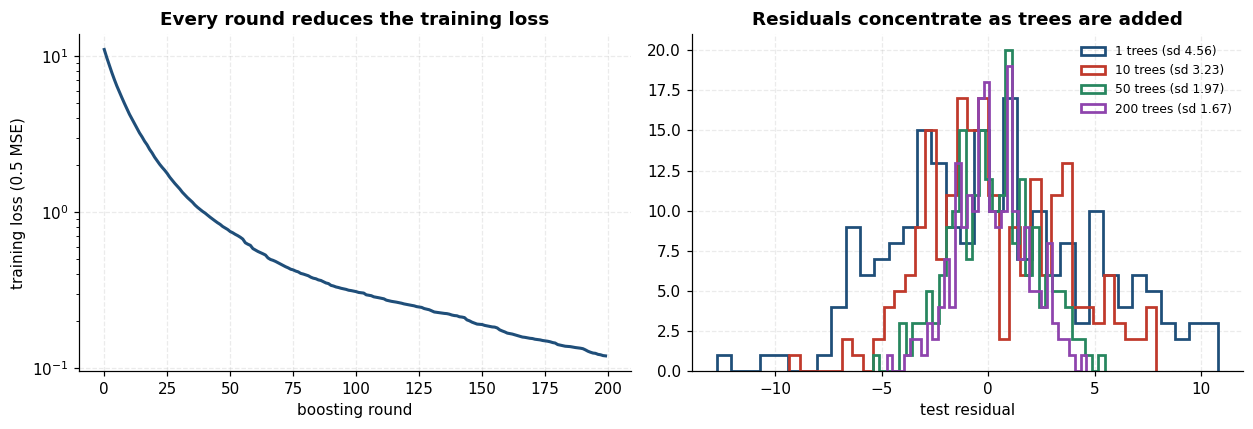

In [4]:
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3,
                                  reg_lambda=1.0, random_state=0).fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
axes[0].plot(model.train_loss_, lw=2)
axes[0].set_xlabel("boosting round")
axes[0].set_ylabel("training loss (0.5 MSE)")
axes[0].set_title("Every round reduces the training loss")
axes[0].set_yscale("log")

staged = list(model.staged_predict(X_test))
for rounds in [1, 10, 50, 200]:
    residual = y_test - staged[rounds - 1]
    axes[1].hist(residual, bins=35, histtype="step", lw=1.8,
                 label=f"{rounds} trees (sd {residual.std():.2f})")
axes[1].set_xlabel("test residual")
axes[1].set_title("Residuals concentrate as trees are added")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Learning rate and number of trees trade off against each other

Shrinkage $\eta$ damps each tree's contribution. Small $\eta$ needs more rounds
but generalises better -- the classic "slow learning" result. Boosting *can*
overfit if run long enough with a large $\eta$, unlike bagging.

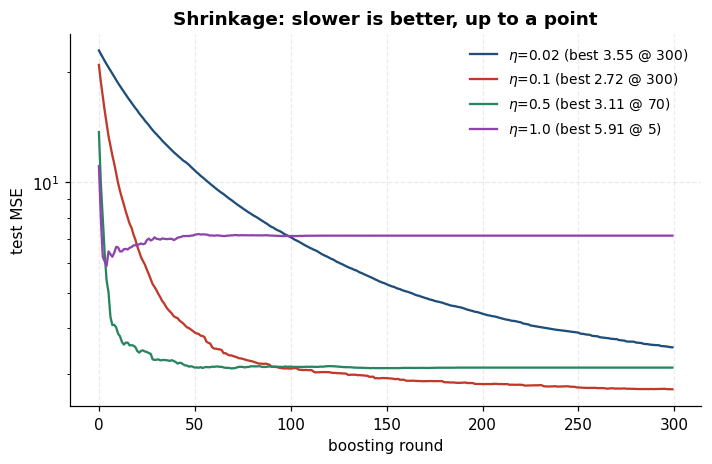

In [5]:
fig, ax = plt.subplots(figsize=(7.4, 4.4))
for eta in [0.02, 0.1, 0.5, 1.0]:
    fit = GradientBoostingRegressor(n_estimators=300, learning_rate=eta, max_depth=3,
                                    random_state=0).fit(X_train, y_train)
    curve = [mse(y_test, p) for p in fit.staged_predict(X_test)]
    ax.plot(curve, label=fr"$\eta$={eta} (best {min(curve):.2f} @ {int(np.argmin(curve)) + 1})")
ax.set_xlabel("boosting round")
ax.set_ylabel("test MSE")
ax.set_title("Shrinkage: slower is better, up to a point")
ax.set_yscale("log")
ax.legend(fontsize=9)
plt.show()

## 4. Early stopping on a validation split

Rather than guessing the number of rounds, hold out a fraction and stop when the
validation loss stops improving. The ensemble is then truncated back to its best
iteration.

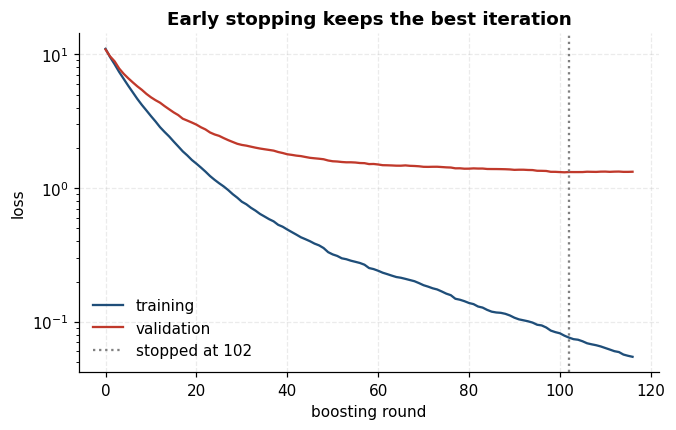

trees kept : 102 of 600
test R^2   : 0.858


In [6]:
early = GradientBoostingRegressor(n_estimators=600, learning_rate=0.1, max_depth=4,
                                  subsample=0.8, colsample=0.7,
                                  validation_fraction=0.2, n_iter_no_change=15,
                                  random_state=0).fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(6.8, 4))
ax.plot(early.train_loss_, label="training")
ax.plot(early.validation_loss_, label="validation")
ax.axvline(early.n_estimators_, color="grey", ls=":", label=f"stopped at {early.n_estimators_}")
ax.set_xlabel("boosting round")
ax.set_ylabel("loss")
ax.set_title("Early stopping keeps the best iteration")
ax.set_yscale("log")
ax.legend()
plt.show()

print(f"trees kept : {early.n_estimators_} of 600")
print(f"test R^2   : {r2_score(y_test, early.predict(X_test)):.3f}")

## 5. Bagging versus boosting

A random forest reduces *variance* by averaging deep, low-bias trees; boosting
reduces *bias* by stacking shallow, high-bias trees. On Friedman #1 the boosted
model wins, and its accumulated split gains recover the informative features.

model                       test R^2  test MSE
single tree (depth 3)          0.524    11.106
random forest                  0.804     4.563
gradient boosting              0.858     3.302



forest out-of-bag R^2: 0.795


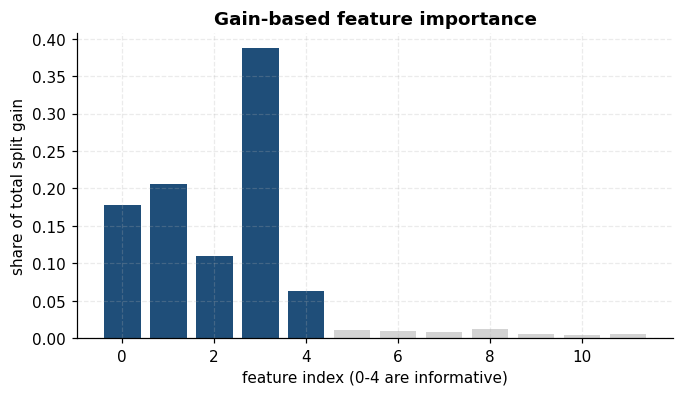

In [7]:
forest = RandomForestRegressor(n_estimators=120, max_depth=10, max_features=0.5,
                               random_state=0).fit(X_train, y_train)

print(f"{'model':<26}{'test R^2':>10}{'test MSE':>10}")
for name, fit in [("single tree (depth 3)", DecisionTreeRegressor(max_depth=3).fit(X_train, y_train)),
                  ("random forest", forest),
                  ("gradient boosting", early)]:
    print(f"{name:<26}{r2_score(y_test, fit.predict(X_test)):>10.3f}"
          f"{mse(y_test, fit.predict(X_test)):>10.3f}")
print(f"\nforest out-of-bag R^2: {forest.oob_score():.3f}")

fig, ax = plt.subplots(figsize=(7, 3.6))
colors = [PALETTE[0] if j < 5 else "lightgrey" for j in range(X.shape[1])]
ax.bar(np.arange(X.shape[1]), early.feature_importances_, color=colors)
ax.set_xlabel("feature index (0-4 are informative)")
ax.set_ylabel("share of total split gain")
ax.set_title("Gain-based feature importance")
plt.show()

## 6. Changing the loss changes only two lines

The tree code never sees the loss -- only $g$ and $h$. Swapping in the logistic
loss, $g_i = p_i - y_i$ and $h_i = p_i(1-p_i)$, turns the regressor into a
classifier whose output is a calibrated probability.

squared error: g = [-0.5 -1.5], h = [1. 1.]
logistic     : g = [-0.378  0.622], h = [0.235 0.235]



test accuracy 0.933 | AUC 0.975 | log loss 0.221


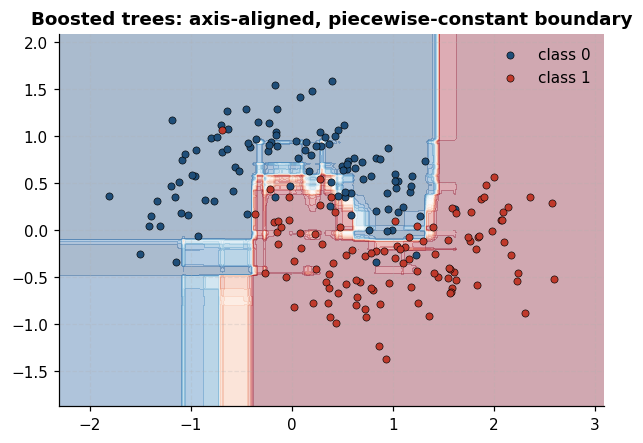

In [8]:
g_sq, h_sq = SquaredError().gradients(np.array([1.0, 2.0]), np.array([0.5, 0.5]))
g_lg, h_lg = LogisticLoss().gradients(np.array([1.0, 0.0]), np.array([0.5, 0.5]))
print(f"squared error: g = {np.round(g_sq, 3)}, h = {np.round(h_sq, 3)}")
print(f"logistic     : g = {np.round(g_lg, 3)}, h = {np.round(h_lg, 3)}")

Xm, ym = make_two_moons(700, noise=0.3, random_state=1)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=0,
                                              stratify=ym)
clf = GradientBoostingClassifier(n_estimators=250, learning_rate=0.1, max_depth=3,
                                 subsample=0.8, random_state=0).fit(Xm_tr, ym_tr)
proba = clf.predict_proba(Xm_te)[:, 1]
print(f"\ntest accuracy {accuracy(ym_te, clf.predict(Xm_te)):.3f} | "
      f"AUC {roc_auc(ym_te, proba):.3f} | log loss {log_loss(ym_te, proba):.3f}")

fig, ax = plt.subplots(figsize=(6.4, 4.4))
plot_decision_boundary(lambda g: clf.predict_proba(g)[:, 1], Xm_te, ym_te, ax=ax,
                       levels=np.linspace(0, 1, 21),
                       title="Boosted trees: axis-aligned, piecewise-constant boundary")
plt.show()

The boundary is visibly built from axis-aligned rectangles -- compare with the
smooth RBF-SVM boundary in notebook 03. Neither is "better"; they encode
different inductive biases, and the shape of the data should decide.

## 7. What to take away

1. Newton boosting fits trees to gradients *and* Hessians; the leaf value
   $-G/(H+\lambda)$ and the gain formula both fall out of one quadratic
   approximation.
2. Shrinkage plus many rounds beats few aggressive rounds; early stopping on a
   validation split removes the guesswork.
3. Row and column subsampling add regularisation and speed at the same time.
4. The loss enters only through $(g, h)$, so new objectives are cheap to add.
5. Boosting reduces bias, bagging reduces variance -- and unlike bagging,
   boosting will overfit if left running.

**Next:** notebook 07 replaces hand-derived gradients with an automatic
differentiation engine.